In [1]:
import os
import seaborn as sns
import matplotlib.pyplot as plt
from skbio import OrdinationResults
%matplotlib inline

#ignore warnings
import warnings
warnings.filterwarnings('ignore')

In [2]:
imic_dir_path = os.path.expanduser('~/NYU Langone Health Dropbox/Bianca Cordazzo Vargas/Shenhav_Lab/IMiC')
joint_rpca_out_path = f'{imic_dir_path}/Code/Joint-RPCA/output/all_tps'
figure_path = f'{imic_dir_path}/Figures/Joint-RPCA'

### MISAME

In [3]:
#load misame ordination results
ord_sapient = OrdinationResults.read(f'{joint_rpca_out_path}/misame_ord_with_untarg_sapient_final.txt')
ord_misame_feats = ord_sapient.features.copy()
ord_misame_feats.rename(columns={0:'PC1', 1:'PC2', 2:'PC3'}, inplace=True)
ord_misame_feats_pc1 = ord_misame_feats.sort_values(by='PC1', ascending=False)
ord_misame_feats_pc1['PC1_rank'] = range(1, len(ord_misame_feats_pc1)+1)

#add columns with features to highlight
feats_ = ['C2', 'C3','C4','C5']
ord_misame_feats_pc1['Cs'] = ord_misame_feats_pc1.index.isin(feats_)

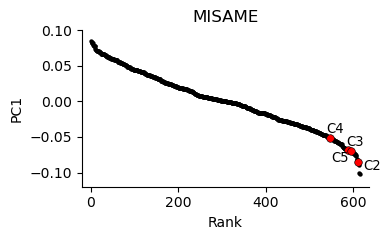

In [4]:
plt.figure(figsize=(4, 2.5))
ax = plt.gca()
sns.scatterplot(x='PC1_rank', y='PC1', s=10, color='black', linewidth=0,
                data=ord_misame_feats_pc1[~ord_misame_feats_pc1['Cs']], ax=ax)
sns.scatterplot(x='PC1_rank', y='PC1', s=30, color='red', edgecolor='k',
                data=ord_misame_feats_pc1[ord_misame_feats_pc1['Cs']], ax=ax)

txt_df = ord_misame_feats_pc1[ord_misame_feats_pc1['Cs']]
for label in txt_df.index:
    if (label!='C5') and (label!='C2'):
        ax.text(x=txt_df.loc[label, 'PC1_rank']-9, y=txt_df.loc[label, 'PC1']+0.007,
                s=label, fontsize=9.5)
    elif (label!='C5') and (label=='C2'):
        ax.text(x=txt_df.loc[label, 'PC1_rank']+10, y=txt_df.loc[label, 'PC1']-0.01,
                s=label, fontsize=9.5)
    else:
        ax.text(x=txt_df.loc[label, 'PC1_rank']-40, y=txt_df.loc[label, 'PC1']-0.017,
                s=label, fontsize=9.5)

plt.xlabel('Rank')
plt.ylabel('PC1')
sns.despine()
plt.title('MISAME')
plt.xlim(-20, 635)
plt.ylim(-0.12, 0.1)
plt.tight_layout()

#save figure
#plt.savefig(f"{figure_path}/Misame_PC1_Cs_ranks_new.pdf",
#         dpi=600, bbox_inches='tight', edgecolor='none')

plt.show()

### Mumta-LW

In [5]:
ord_vital = OrdinationResults.read(f'{joint_rpca_out_path}/vital_ord_with_untarg_sapient_v3.txt')
ord_vital_feats = ord_vital.features.copy()
ord_vital_feats.rename(columns={0:'PC1', 1:'PC2', 2:'PC3'}, inplace=True)
ord_vital_feats_pc1 = ord_vital_feats.sort_values(by='PC1', ascending=False)
ord_vital_feats_pc1['PC1_rank'] = range(1, len(ord_vital_feats_pc1)+1)

#add columns with features to highlight
feats_ = ['C2', 'C3','C4','C5']
ord_vital_feats_pc1['Cs'] = ord_vital_feats_pc1.index.isin(feats_)

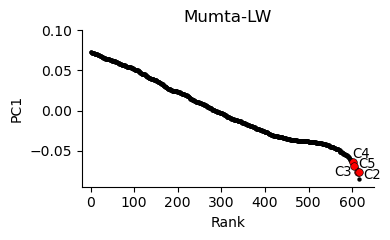

In [6]:
plt.figure(figsize=(4, 2.5))
ax = plt.gca()
sns.scatterplot(x='PC1_rank', y='PC1', s=10, color='black', linewidth=0,
                data=ord_vital_feats_pc1[~ord_vital_feats_pc1['Cs']], ax=ax)
sns.scatterplot(x='PC1_rank', y='PC1', s=30, color='red', edgecolor='k', 
                data=ord_vital_feats_pc1[ord_vital_feats_pc1['Cs']], ax=ax)

txt_df = ord_vital_feats_pc1[ord_vital_feats_pc1['Cs']]
for label in txt_df.index:
    if (label!='C3') and (label!='C2'):
        ax.text(x=txt_df.loc[label, 'PC1_rank'], y=txt_df.loc[label, 'PC1']+0.005,
                s=label, fontsize=9.5)
    elif label=='C3':
        ax.text(x=txt_df.loc[label, 'PC1_rank']-45, y=txt_df.loc[label, 'PC1']-0.013,
                s=label, fontsize=9.5)
    elif label=='C2':
        ax.text(x=txt_df.loc[label, 'PC1_rank']+10, y=txt_df.loc[label, 'PC1']-0.008,
                s=label, fontsize=9.5)
    else:
        continue

plt.xlabel('Rank')
plt.ylabel('PC1')
sns.despine()
plt.title('Mumta-LW')
plt.xlim(-20, 650)
plt.ylim(-0.095, 0.1)
plt.tight_layout()

#save figure
#plt.savefig(f"{figure_path}/Vital_PC1_Cs_ranks_new.pdf",
#         dpi=600, bbox_inches='tight', edgecolor='none')

plt.show()